<a href="https://colab.research.google.com/github/soup511/ML/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('heart.csv')

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


EDA

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


In [10]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


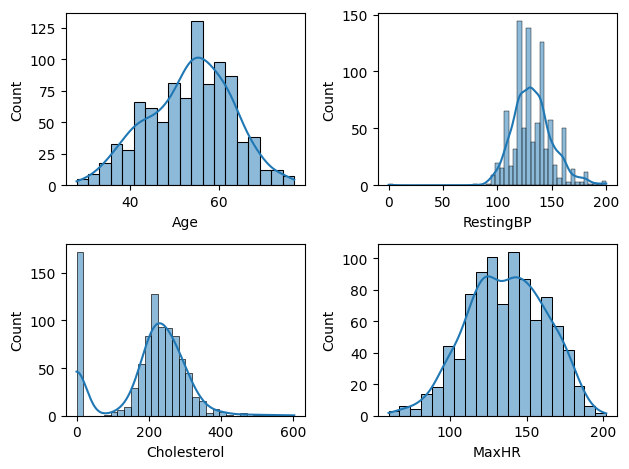

In [11]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [12]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [13]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

In [14]:
r_bp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace(0,ch_mean)
df['RestingBP']=df['RestingBP'].round(2)

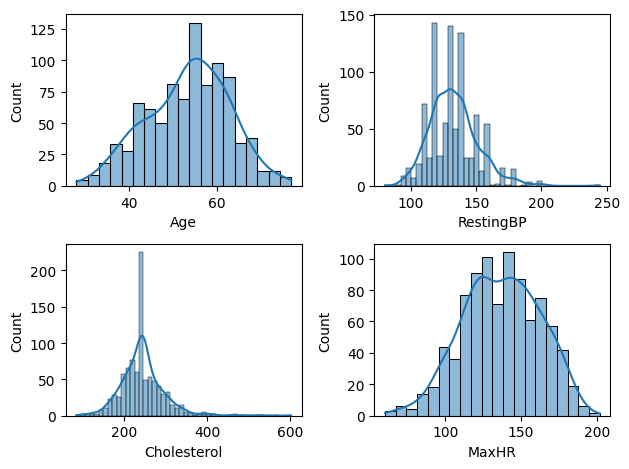

In [15]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

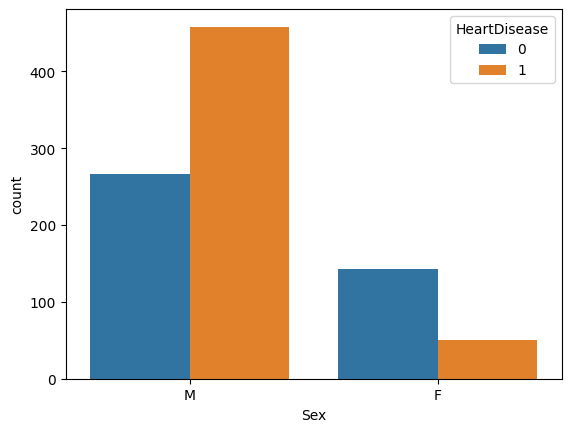

In [16]:
sns.countplot(x='Sex',hue='HeartDisease',data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

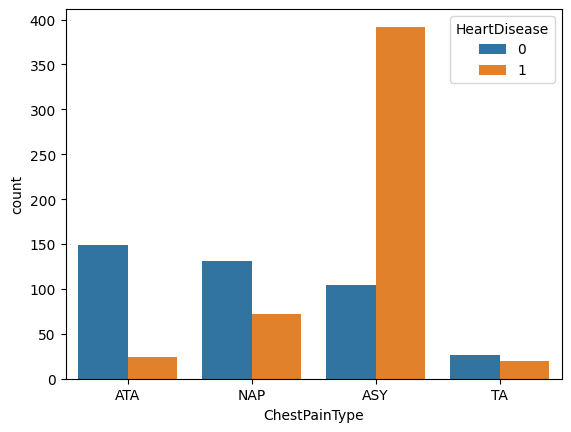

In [17]:
sns.countplot(x='ChestPainType',hue='HeartDisease',data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

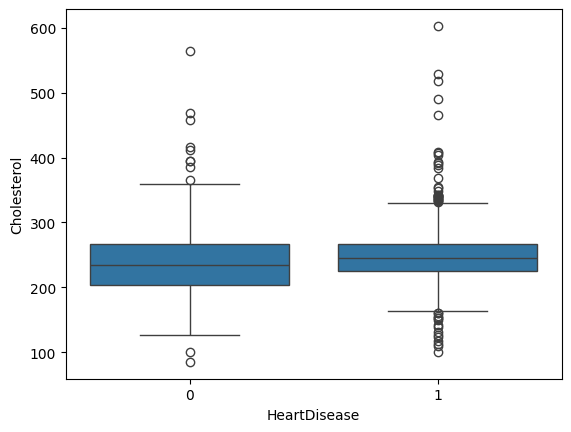

In [18]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)

data preprocessing

In [19]:
df_encode=pd.get_dummies(df,drop_first=True)

In [20]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [21]:
df_encode=df_encode.astype(int)

In [22]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [23]:
from sklearn.preprocessing import StandardScaler
numacical_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler=StandardScaler()
df_encode[numacical_cols]=scaler.fit_transform(df_encode[numacical_cols])

In [24]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [26]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [42]:
x=df_encode.drop('HeartDisease',axis=1)
y=df_encode['HeartDisease']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

In [44]:
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

In [45]:
models={
    'LogisticRegression':LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier()
}


In [54]:
result=[]

In [55]:
for name,model in models.items():
    model.fit(X_train_sc,y_train)
    y_pred=model.predict(X_test_sc)
    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    result.append({'name':name,'accuracy':round(accuracy,4),'f1':round(f1,4)})

In [56]:
result

[{'name': 'LogisticRegression', 'accuracy': 0.8614, 'f1': 0.8772},
 {'name': 'GaussianNB', 'accuracy': 0.8515, 'f1': 0.8673},
 {'name': 'DecisionTreeClassifier', 'accuracy': 0.7327, 'f1': 0.7553},
 {'name': 'SVC', 'accuracy': 0.8548, 'f1': 0.8728},
 {'name': 'KNeighborsClassifier', 'accuracy': 0.8548, 'f1': 0.8713}]

In [58]:
import joblib
joblib.dump(models['LogisticRegression'],'heart_disease.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist,'columns.pkl')

['columns.pkl']

In [62]:
!pip install streamlit

In [64]:

import streamlit as st
import pandas as pd
import joblib

model = joblib.load('heart_disease.pkl')
scaler=joblib.load('scaler.pkl')
expected_columns=joblib.load('columns.pkl')
st.title('Heart Disease Prediction')
st.markdown('This app predicts the likelihood of heart disease based on user input features.')
age=st.slider('Age', 0, 100, 50)
sex=st.selectbox('Sex', ['Male', 'Female'])
cp=st.selectbox('Chest Pain Type', ['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])
restbps=st.slider('Resting Blood Pressure (mm Hg)', 80, 200, 120)
chol=st.slider('Serum Cholesterol (mg/dl)', 100, 600, 200)
fbs=st.selectbox('Fasting Blood Sugar > 120 mg/dl', ['  Yes', 'No'])
restecg=st.selectbox('Resting Electrocardiographic Results', ['Normal', 'ST-T Wave Abnormality', 'Left Ventricular Hypertrophy'])
maxhr=st.slider('Maximum Heart Rate Achieved', 60, 220, 150)
exang=st.selectbox('Exercise Induced Angina', ['Yes', 'No'])
oldpeak=st.slider('ST Depression Induced by Exercise Relative to Rest', 0.0, 10.0, 1.0)
slope=st.selectbox('Slope of the Peak Exercise ST Segment', ['Upsloping', 'Flat', 'Downsloping'])


if st.button('Predict'):
    raw_input = {
        'age': age,
        'resting_blood_pressure': restbps,
        'serum_cholesterol': chol,
        'maximum_heart_rate': maxhr,
        'st_depression': oldpeak,
        'sex_' + sex: 1,
        'chest_pain_type_' + cp: 1,
        'fasting_blood_sugar_' + fbs.strip(): 1,
        'resting_ecg_' + restecg: 1,
        'slope_' + slope: 1,
        'Exercise_induced_angina_' + exang: 1,
    }
    input_df = pd.DataFrame([raw_input])
    for col in expected_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[expected_columns]
    prediction=model.predict(scaler.transform(input_df))[0]
    if prediction == 1:
        st.error('The model predicts that you are likely to have heart disease. Please consult a healthcare professional for further evaluation.')
    else:
        st.success('The model predicts that you are unlikely to have heart disease. However, it is always recommended to consult a healthcare professional for a comprehensive assessment.')

2026-08-27 13:10:36.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 13:10:36.433 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar